 # 1. Wstęp - opis zbioru

Problem, można traktować zarówno jako zadanie regresji jak i klasyfikacji. Ja traktuje to jako zadanie **klasyfikacji**

Opis zbioru

Na podstawie tego zbioru nauczę model do predykcji półki cenowej telefonu. "Firma" będzie go wykorzystywać do szacowania ceny telefonu na podstawie parametrów technicznych.

Dane:
- `Indeks` - liczba porządkowa rekordu. W .csv nie ma tytułu.
- `battery_power` - pojemność baterii (mAh)
- `blue` - czy posiada bluetootha
- `clock_speed` - taktowanie procesora (GHz)
- `dual_sim` - czy posiada dwa miejsca na kartę sim (0 - nie, 1 - tak)
- `fc` - ilość megapikseli kamery
- `four_g` - czy telefon obsługuje 4g
- `int_memory` - pamięć wewnętrzna (Gb)
- `m_dep` - głębokość telefonu (cm)
- `mobile_wt` - waga telefonu (g)
- `n_cores` - liczba rdzeni procesora
- `pc` - ilość megapikseli głównej kamery
- `px_width` - rozmiar zdjęć w pikselach
- `px_height` - wysokość zdjęć w pikselach
- `ram` - ilość ramu (Mb)
- `sc_width` - rozmiar ekranu w pikselach
- `sc_height` - wysokość ekranu w pikselach
- `talk_time` - czas rozmowy telefonicznej, po którym bateria się rozładuje.
- `three_g` - czy ma 3g (0 - nie, 1 - tak)
- `touch_screen` - czy ma ekran dotykowy (0 - nie, 1 - tak)
- `wifi` - wifi

Etykiety:
- `price_range` - półka cenowa telefonu

In [180]:
import pandas as pd
import sklearn
import keras
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Spójrzmy na dane za nim co kolwiek zrobimy

In [181]:
raw_df = pd.read_csv("dataset.csv", index_col="Unnamed: 0")
raw_df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,no,2.2,0,1,no,7,0.6,188,2,...,20,756,2549.0,9,7,19.0,0,0,wifi,medium cost
1,1021,yes,0.5,1,0,yes,53,0.7,136,3,...,905,1988,2631.0,17,3,7.0,1,1,no_wifi,high cost
2,563,yes,0.5,1,2,yes,41,0.9,145,5,...,1263,1716,2603.0,11,2,9.0,1,1,no_wifi,high cost
3,615,yes,2.5,0,0,no,10,0.8,131,6,...,1216,1786,2769.0,16,8,11.0,1,0,no_wifi,high cost
4,1821,yes,1.2,0,13,yes,44,0.6,141,2,...,1208,1212,1411.0,8,2,15.0,1,1,no_wifi,medium cost
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,yes,0.5,1,0,yes,2,0.8,106,6,...,1222,1890,668.0,13,4,19.0,1,1,no_wifi,low cost
1996,1965,yes,2.6,1,0,no,39,0.2,187,4,...,915,1965,2032.0,11,10,16.0,1,1,wifi,high cost
1997,1911,no,0.9,1,1,yes,36,0.7,108,8,...,868,1632,3057.0,9,1,5.0,1,1,no_wifi,very high cost
1998,1512,no,0.9,0,4,yes,46,0.1,145,5,...,336,670,869.0,18,10,19.0,1,1,wifi,low cost


In [182]:
raw_df.describe()

,battery_power,clock_speed,dual_sim,fc,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen
count,1935.000000,1935.000000,1935.000000,1935.000000,1935.000000,1935.000000,1935.000000,1935.000000,1935.000000,1935.000000,1935.000000,1913.000000,1935.000000,1935.000000,1873.000000,1935.000000,1935.000000
mean,1240.282687,1.528889,0.509044,4.298708,32.115245,0.504703,140.209819,4.529716,9.932817,646.829457,1255.708527,2120.500784,12.322997,5.757623,10.998398,0.762274,0.501809
std,438.590972,0.820332,0.500047,4.345792,18.161480,0.292660,35.480487,2.285474,6.057774,445.042126,434.465962,1083.400626,4.209676,4.333399,5.457734,0.425801,0.500126
min,501.000000,0.500000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,0.000000,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000
25%,853.500000,0.700000,0.000000,1.000000,16.000000,0.200000,109.000000,3.000000,5.000000,284.500000,880.000000,1205.000000,9.000000,2.000000,6.000000,1.000000,0.000000
50%,1231.000000,1.500000,1.000000,3.000000,32.000000,0.500000,141.000000,4.000000,10.000000,567.000000,1251.000000,2131.000000,12.000000,5.000000,11.000000,1.000000,1.000000
75%,1617.000000,2.250000,1.000000,7.000000,48.000000,0.800000,170.000000,7.000000,15.000000,948.000000,1638.500000,3056.000000,16.000000,9.000000,16.000000,1.000000,1.000000
max,1998.000000,4.000000,1.000000,19.000000,64.000000,2.000000,200.000000,8.000000,20.000000,1960.000000,2298.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000


Super. Popatrzyliśmy na dane w tabelce.


imo można wywalić pewne kolumny:
- Unnamed: 0 - losowy indeksik, niby można użyć jako key przy wczytaniu
- pc i fc są podobne więc wywaliłbym fc, tak dla beki
- sc_h i sc_w z opisu zbioru są zapisane jako rozmiar ekranu w pikselach, ale dlaczego ich wartości są takie małe?

Zauważamy, że `blue`, `four_g`, `wifi` kodował jakiś humanista i trzeba to przerobić na prawilną binarkę jak w `three_g` `touch_screen`, `dual_sim`

also nie ufałbym wartościom w `m_dep` serio telefon ma 1 mm *grubości* (głębokości)? 

In [183]:
raw_df = raw_df.drop(columns=["fc", "m_dep", "sc_h", "sc_w"])

In [184]:
raw_df

,battery_power,blue,clock_speed,dual_sim,four_g,int_memory,mobile_wt,n_cores,pc,px_height,px_width,ram,talk_time,three_g,touch_screen,wifi,price_range
0,842,no,2.2,0,no,7,188,2,2,20,756,2549.0,19.0,0,0,wifi,medium cost
1,1021,yes,0.5,1,yes,53,136,3,6,905,1988,2631.0,7.0,1,1,no_wifi,high cost
2,563,yes,0.5,1,yes,41,145,5,6,1263,1716,2603.0,9.0,1,1,no_wifi,high cost
3,615,yes,2.5,0,no,10,131,6,9,1216,1786,2769.0,11.0,1,0,no_wifi,high cost
4,1821,yes,1.2,0,yes,44,141,2,14,1208,1212,1411.0,15.0,1,1,no_wifi,medium cost
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,yes,0.5,1,yes,2,106,6,14,1222,1890,668.0,19.0,1,1,no_wifi,low cost
1996,1965,yes,2.6,1,no,39,187,4,3,915,1965,2032.0,16.0,1,1,wifi,high cost
1997,1911,no,0.9,1,yes,36,108,8,3,868,1632,3057.0,5.0,1,1,no_wifi,very high cost
1998,1512,no,0.9,0,yes,46,145,5,5,336,670,869.0,19.0,1,1,wifi,low cost


# 3. Preprocessing

In [185]:
sklearn.set_config(transform_output="pandas")

### 3.1 Preprocessing - Brakujące wartości

In [186]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1935 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  1935 non-null   int64  
 1   blue           1915 non-null   object 
 2   clock_speed    1935 non-null   float64
 3   dual_sim       1935 non-null   int64  
 4   four_g         1935 non-null   object 
 5   int_memory     1935 non-null   int64  
 6   mobile_wt      1935 non-null   int64  
 7   n_cores        1935 non-null   int64  
 8   pc             1935 non-null   int64  
 9   px_height      1935 non-null   int64  
 10  px_width       1935 non-null   int64  
 11  ram            1913 non-null   float64
 12  talk_time      1873 non-null   float64
 13  three_g        1935 non-null   int64  
 14  touch_screen   1935 non-null   int64  
 15  wifi           1935 non-null   object 
 16  price_range    1935 non-null   object 
dtypes: float64(3), int64(10), object(4)
memory usage: 272.1+ 

In [187]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelBinarizer

# scaler = sklearn.preprocessing.StandardScaler()

# X_to_scale = X_transformed.drop(columns=["dual_sim", "touch_screen", "three_g","blue_no", "blue_yes", "four_g_no", "four_g_yes", "wifi_no_wifi", "wifi_wifi"])
# X_scaled = scaler.fit_transform(X_to_scale)

# X_final = pd.concat([X_transformed[["dual_sim", "touch_screen", "three_g","blue_no", "blue_yes", "four_g_no", "four_g_yes", "wifi_no_wifi", "wifi_wifi"]], X_scaled], axis=1)

# Chcemy podzielić zbiór na zbiory treningowy i testowy
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(raw_df, test_size=0.3, random_state=42)
# Teraz podzielimy zbiory na cechy (X) i etykiety (y)

X_train = train_df.drop(columns=["price_range"])
y_train = train_df["price_range"]
X_test = test_df.drop(columns=["price_range"])
y_test = test_df["price_range"]

# Teraz możemy stworzyć pipeline do przetwarzania danych
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object', 'bool']).columns
label_encoder = LabelBinarizer()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
    ])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
        ])

# Teraz możemy dopasować i przekształcić dane treningowe
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# chcemy OneHotEncode nasze etykiety
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

### 3.2 Preprocessing - Dane tekstowe

In [188]:
# df_categorical_imputed

In [189]:
# from sklearn.preprocessing import OneHotEncoder

# oh = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# df_categorical_encoded = oh.fit_transform(df_categorical_imputed)
# df_categorical_encoded

In [190]:
# df_transformed = pd.concat([df_numeric_imputed, df_categorical_encoded], axis=1)

# X_transformed = df_transformed.drop(columns=["price_range_high cost", "price_range_low cost", "price_range_medium cost", "price_range_very high cost"])
# y_transformed = df_transformed[["price_range_high cost", "price_range_low cost", "price_range_medium cost", "price_range_very high cost"]]

# X_transformed

### 3.3 Preprocessing - Skalowanie
Pamiętajmy, że nie chcemy skalować etykiet i danych zero-jeden, bo skończymy tak:


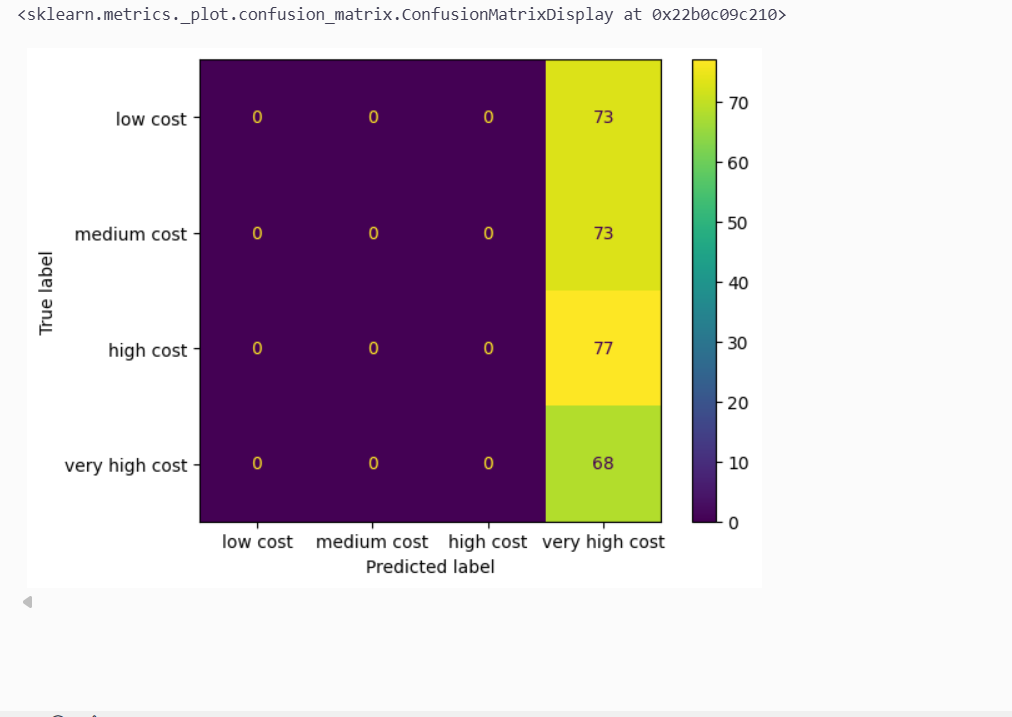

In [191]:
# df_final = pd.concat([X_final, y_transformed], axis=1)
# df_final

# 4. Model

In [192]:
X_valid, X_test, y_valid, y_test = sklearn.model_selection.train_test_split(X_test, y_test, test_size=0.5, random_state=42)

In [ ]:
model = keras.Sequential([
    keras.layers.Input(shape=(X_train_transformed.shape[1],)),
    keras.layers.Dense(128, activation='sigmoid'),
    keras.layers.Dense(64, activation='sigmoid'),
    keras.layers.Dense(4, activation='softmax'),
])

In [194]:
def display_history(history):
    sns.lineplot(history.history)
    plt.grid()
    plt.xlabel("Epoch")
    plt.ylabel("Value")

In [195]:
initial_weights = model.get_weights()

**categorical_crossentropy**:
- Mam 4 etykiety 
- Używam softmaxa bo chce mieć 0 i 1 jako predykcje
- Moje etykiety to OH encoded wektor dlatego CCE.

Gdybym obliczał strate według pojedyńczego indeksu (np. 1 dla medium cost) a nie wektora [0,1,0,0] użył bym *Sparse Categorical Cross-Entropy*

In [196]:
optimizer = keras.optimizers.Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

model.set_weights(initial_weights)

In [ ]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
)

history = model.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid), callbacks=[early_stopping, reduce_lr], verbose=1)
display_history(history)   

AttributeError: 'numpy.ndarray' object has no attribute 'to_frame'

In [ ]:
model_predictions = model.predict(X_test)
model_predictions

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


array([[5.25477994e-10, 1.20642490e-03, 5.09572885e-07, 9.98793125e-01],
       [1.22019104e-04, 9.36406434e-01, 5.01904860e-02, 1.32810986e-02],
       [8.65444633e-07, 9.97357547e-01, 4.10668086e-04, 2.23091850e-03],
       ...,
       [3.01314529e-10, 7.16307317e-04, 3.11301051e-07, 9.99283373e-01],
       [7.63080828e-03, 4.60429937e-02, 9.29123342e-01, 1.72028188e-02],
       [2.83520762e-10, 6.49681431e-04, 2.77923391e-07, 9.99350131e-01]],
      shape=(291, 4), dtype=float32)

# 5. Ocena predykcji

### 5.1 Accuracy

In [ ]:
sklearn.metrics.accuracy_score(model_predictions.argmax(axis=1), y_test.values.argmax(axis=1))

0.9656357388316151

### 5.2 Confusion Matrix


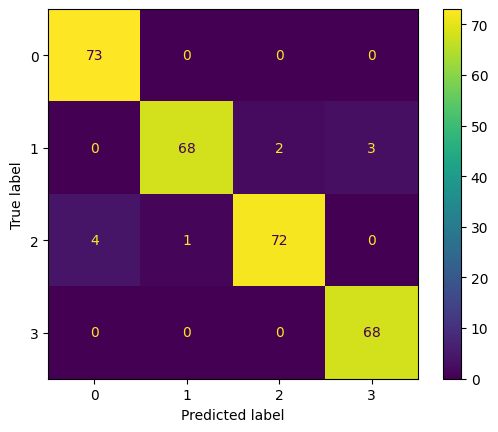

In [ ]:
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(y_test.values.argmax(axis=1), model_predictions.argmax(axis=1))

### 5.3 Precision, Recall, F1

In [ ]:
print(sklearn.metrics.classification_report(y_test.values.argmax(axis=1), model_predictions.argmax(axis=1), target_names=["low cost", "medium cost", "high cost", "very high cost"]))

                precision    recall  f1-score   support

      low cost       0.95      1.00      0.97        73
   medium cost       0.99      0.93      0.96        73
     high cost       0.97      0.94      0.95        77
very high cost       0.96      1.00      0.98        68

      accuracy                           0.97       291
     macro avg       0.97      0.97      0.97       291
  weighted avg       0.97      0.97      0.97       291



### 5.4 Sprawdzenie overfittingu
Generalnie przyjmuje, że jeśli accuracy $Train \gg Test$  to jest overfitting ( $\gg$ - znacznie większe)

In [ ]:
train_loss, train_accuracy = model.evaluate(X_train, y_train, verbose=0)
valid_loss, valid_accuracy = model.evaluate(X_valid, y_valid, verbose=0)
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Valid Accuracy: {valid_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Train Accuracy: 0.9793
Valid Accuracy: 0.9310
Test Accuracy: 0.9656
